## Test : Simulated Dataset

In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import gpytorch
from scipy.stats import nbinom, spearmanr
from scipy.special import gammaln
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [54]:
def generate_simulation_data(N=300, G=5, D=5):
    n_clusters = 4
    sizes = [N // 4] * (n_clusters - 1) + [N - 3 * (N // 4)]
    centers = np.array([
        [-1.5, -1.0,  0.5,  0.2, -0.8],
        [ 1.5,  0.5, -0.5, -0.3,  0.6],
        [ 0.0,  1.5,  1.0, -1.0,  0.3],
        [-0.5, -1.5, -1.0,  1.5,  1.0],
    ])[:, :D]
    X = np.vstack([np.random.randn(s, D) * 0.4 + c for s, c in zip(sizes, centers)]).astype(np.float32)

    n_linear    = max(1, int(G * 0.4))
    n_nonlinear = max(1, int(G * 0.4))
    n_null      = G - n_linear - n_nonlinear
    gene_groups = ['linear'] * n_linear + ['nonlinear'] * n_nonlinear + ['null'] * n_null

    thetas = np.concatenate([
        np.random.uniform(3, 8, n_linear),
        np.random.uniform(0.5, 2, n_nonlinear),
        np.random.uniform(5, 10, n_null),
    ]).astype(np.float32)

    Y       = np.zeros((N, G), dtype=np.float32)
    true_mu = np.zeros((N, G), dtype=np.float32)
    true_pi = np.zeros((N, G), dtype=np.float32)

    for g in range(G):
        grp, theta_g = gene_groups[g], thetas[g]

        if grp == 'linear':
            log_mu = np.random.uniform(1.0, 2.5) + X @ (np.random.randn(D).astype(np.float32) * 0.5)
        elif grp == 'nonlinear':
            b = np.random.randn(D).astype(np.float32) * 0.4
            log_mu = (np.random.uniform(1.0, 2.0)
                      + b[0] * np.sin(X[:, 0] * 1.5)
                      + b[1] * (X[:, 1] ** 2) * 0.3
                      + b[2] * X[:, 2]
                      + (b[3] * X[:, 3] if D > 3 else 0)
                      + (b[4] * X[:, 4] if D > 4 else 0))
        else:
            log_mu = np.full(N, np.random.uniform(1.5, 2.5), dtype=np.float32)

        mu_g = np.clip(np.exp(log_mu), 1e-3, 1e4).astype(np.float32)

        logit_pi = (np.random.uniform(-2.0, -0.5)
                    + np.random.uniform(-0.8, 0.0) * X[:, 0]
                    + np.random.uniform(-0.5, 0.5) * X[:, min(2, D - 1)])
        pi_g = (1.0 / (1.0 + np.exp(-logit_pi))).astype(np.float32)

        true_mu[:, g] = mu_g
        true_pi[:, g] = pi_g

        p_nb = np.clip(mu_g / (mu_g + theta_g), 1e-6, 1 - 1e-6)
        counts = np.random.negative_binomial(theta_g, 1 - p_nb).astype(np.float32)
        counts[np.random.rand(N) < pi_g] = 0.0
        Y[:, g] = counts

    return torch.tensor(X), torch.tensor(Y), torch.tensor(true_mu), torch.tensor(true_pi), gene_groups, thetas

N, G, D = 300, 10, 5  # Adjusted G for display simplicity, feel free to increase
X, Y, true_mu, true_pi, gene_groups, true_thetas = generate_simulation_data(N=N, G=G, D=D)

split = int(0.8 * N)
X_tr, X_te      = X[:split], X[split:]
Y_tr, Y_te      = Y[:split], Y[split:]
mu_te_true      = true_mu[split:]

print(f"N_train={split}, N_test={N - split}, G={G}, D={D}")
print(f"zero rate: {(Y == 0).float().mean():.3f}")
print(f"gene groups: {gene_groups}")
print(f"true thetas: {true_thetas.round(2)}")

N_train=240, N_test=60, G=10, D=5
zero rate: 0.300
gene groups: ['linear', 'linear', 'linear', 'linear', 'nonlinear', 'nonlinear', 'nonlinear', 'nonlinear', 'null', 'null']
true thetas: [4.35 7.13 5.49 3.39 0.59 1.   1.68 1.56 8.94 7.59]


In [55]:
# =====================================================================
# 2. Models: Laplace NB-GP
# =====================================================================
class LaplaceNBGP(nn.Module):
    def __init__(self, n_features, theta_init=2.0):
        super().__init__()
        self.log_output_scale = nn.Parameter(torch.zeros(1))
        self.log_length_scale = nn.Parameter(torch.zeros(n_features))
        self.raw_theta = nn.Parameter(torch.tensor(float(np.log(np.exp(theta_init) - 1.0 + 1e-6))))

    @property
    def theta(self):
        return nn.functional.softplus(self.raw_theta) + 0.1

    def kernel(self, X1, X2=None):
        if X2 is None: X2 = X1
        ls = self.log_length_scale.exp()
        os = self.log_output_scale.exp()
        diff = (X1.unsqueeze(1) - X2.unsqueeze(0)) / ls
        return os * (-0.5 * diff.pow(2).sum(-1)).exp()

    @staticmethod
    def _nb_grad_W(f, y, theta):
        mu = f.exp().clamp(1e-4, 1e4)
        grad = y - mu * (y + theta) / (mu + theta)
        W = (mu * theta * (y + theta) / (mu + theta).pow(2)).clamp(1e-8)
        return grad, W

    def _safe_cholesky(self, A):
        for jitter in [1e-4, 1e-3, 1e-2, 1e-1]:
            try: return torch.linalg.cholesky(A + jitter * torch.eye(len(A)))
            except Exception: continue
        raise RuntimeError("Cholesky failed")

    def find_map(self, K, y, f0=None, max_iter=50, tol=1e-5):
        n, theta = len(y), self.theta.detach()
        f = f0.detach().clone() if f0 is not None else torch.zeros(n)
        with torch.no_grad():
            for _ in range(max_iter):
                grad, W = self._nb_grad_W(f, y, theta)
                sqrt_W = W.sqrt()
                B = torch.eye(n) + sqrt_W[:, None] * K * sqrt_W[None, :]
                try: L = self._safe_cholesky(B)
                except RuntimeError: break
                b = W * f + grad
                v = torch.cholesky_solve((sqrt_W * (K @ b))[:, None], L).squeeze()
                f_new = K @ (b - sqrt_W * v)
                if (f_new - f).norm().item() < tol: return f_new
                f = f_new
        return f

    def log_marginal_lik(self, K, f_map, y):
        theta, f = self.theta, f_map.detach()
        _, W = self._nb_grad_W(f, y, theta)
        sqrt_W = W.clamp(1e-8).sqrt()
        B = torch.eye(len(y)) + sqrt_W[:, None] * K * sqrt_W[None, :]
        try: L = self._safe_cholesky(B)
        except RuntimeError: return K.sum() * 0.0 - 1e8
        
        mu = f.exp().clamp(1e-4, 1e4)
        log_lik = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1)
                   + theta * (theta.log() - (theta + mu).log())
                   + y * (mu.log() - (theta + mu).log())).sum()
        K_chol = self._safe_cholesky(K)
        alpha = torch.cholesky_solve(f[:, None], K_chol).squeeze()
        log_prior = -0.5 * (f * alpha).sum()
        log_det = -L.diagonal().log().sum()
        return log_lik + log_prior + log_det

    def posterior_predictive(self, K_train, f_map, y, K_cross, k_test_diag):
        theta, f = self.theta.detach(), f_map.detach()
        grad, W = self._nb_grad_W(f, y, theta)
        sqrt_W = W.sqrt()
        B = torch.eye(len(y)) + sqrt_W[:, None] * K_train * sqrt_W[None, :]
        try: L = self._safe_cholesky(B)
        except RuntimeError: return torch.zeros(k_test_diag.shape), k_test_diag

        f_mean = K_cross.T @ grad
        v = torch.linalg.solve_triangular(L, sqrt_W[:, None] * K_cross, upper=False)
        f_var = (k_test_diag - v.pow(2).sum(0)).clamp(0)
        return f_mean, f_var

def train_laplace_nbgp(X_train, y_train, max_epochs=200):
    model = LaplaceNBGP(X_train.shape[-1])
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    f_map = torch.zeros(len(y_train))
    for _ in range(max_epochs):
        model.eval()
        with torch.no_grad():
            f_map = model.find_map(model.kernel(X_train), y_train, f0=f_map)
        model.train()
        opt.zero_grad()
        try: loss = -model.log_marginal_lik(model.kernel(X_train), f_map, y_train)
        except Exception: continue
        if torch.isnan(loss): continue
        loss.backward()
        opt.step()
    
    model.eval()
    with torch.no_grad(): f_map = model.find_map(model.kernel(X_train), y_train, f0=f_map)
    return model, f_map.detach()


# =====================================================================
# 3. Models: Full Variational Inference NB-GP (Added)
# =====================================================================
class VINGBLikelihood(gpytorch.likelihoods.Likelihood):
    def __init__(self):
        super().__init__()
        self.raw_theta = nn.Parameter(torch.tensor(0.0))
        
    @property
    def theta(self):
        return nn.functional.softplus(self.raw_theta) + 1e-4
        
    def forward(self, function_samples, **kwargs):
        # PyTorch NB distribution parameterization:
        # logits = log(mu / theta). Since f = log(mu), logits = f - log(theta)
        logits = function_samples - torch.log(self.theta)
        return torch.distributions.NegativeBinomial(total_count=self.theta, logits=logits)

class VINBGP(gpytorch.models.ApproximateGP):
    def __init__(self, X_train):
        var_dist = gpytorch.variational.CholeskyVariationalDistribution(X_train.size(0))
        var_strat = gpytorch.variational.VariationalStrategy(
            self, X_train, var_dist, learn_inducing_locations=False
        )
        super().__init__(var_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=X_train.size(-1)))

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(self.mean_module(x), self.covar_module(x))

def train_vi_nbgp(X_train, y_train, max_epochs=300):
    model = VINBGP(X_train)
    likelihood = VINGBLikelihood()
    model.train(); likelihood.train()
    
    opt = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': likelihood.parameters()}
    ], lr=0.05)
    
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y_train.size(0))
    
    for _ in range(max_epochs):
        opt.zero_grad()
        output = model(X_train)
        loss = -mll(output, y_train)
        loss.backward()
        opt.step()
        
    model.eval(); likelihood.eval()
    return model, likelihood

# =====================================================================
# 4. Hurdle GP (Legacy code preserved for df metrics)
# =====================================================================
class ExactGaussianGP(gpytorch.models.ExactGP):
    def __init__(self, X, y, likelihood):
        super().__init__(X, y, likelihood)
        self.mean = gpytorch.means.ConstantMean()
        self.covar = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=X.shape[-1]))
    def forward(self, x): return gpytorch.distributions.MultivariateNormal(self.mean(x), self.covar(x))

def train_hurdle_gene(X_train, y_train):
    is_nz = (y_train.numpy() > 0).astype(int)
    lr_model = LogisticRegression(penalty=None, max_iter=200).fit(X_train.numpy(), is_nz) if sum(is_nz) > 1 else None
    
    nz_mask = y_train > 0
    gp_model = gp_lik = None
    if nz_mask.sum() >= 10:
        X_nz, y_nz = X_train[nz_mask], torch.log(y_train[nz_mask] + 1.0)
        gp_lik = gpytorch.likelihoods.GaussianLikelihood()
        gp_model = ExactGaussianGP(X_nz, y_nz, gp_lik)
        gp_model.train(); gp_lik.train()
        opt = torch.optim.Adam([*gp_model.parameters(), *gp_lik.parameters()], lr=0.05)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(gp_lik, gp_model)
        for _ in range(200):
            opt.zero_grad()
            try: loss = -mll(gp_model(X_nz), y_nz)
            except Exception: continue
            loss.backward(); opt.step()
        gp_model.eval(); gp_lik.eval()
    return lr_model, gp_model, gp_lik

# =====================================================================
# 5. Metrics & Utilities
# =====================================================================
def nb_loglik(y_np, mu_np, theta):
    y, mu, th = y_np.astype(np.float64), np.clip(mu_np.astype(np.float64), 1e-8, 1e6), float(theta)
    return (gammaln(y + th) - gammaln(th) - gammaln(y + 1)
            + th * np.log(th / (th + mu)) + y * np.log(mu / (th + mu) + 1e-12)).mean()

def safe_spearman_corr(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if a.std() < 1e-8 or b.std() < 1e-8: return float('nan')
    corr, _ = spearmanr(a, b)
    return float(corr) if not np.isnan(corr) else float('nan')

In [57]:
results = []
pred_arrays = {}

for g in range(G):
    y_tr, y_te = Y_tr[:, g], Y_te[:, g]
    mu_true = mu_te_true[:, g].numpy()
    
    print(f"Fitting Gene {g+1}/{G} ({gene_groups[g]})...")
    
    # 1. GLM
    print("  Training GLM...")
    X_tr_np = sm.add_constant(X_tr.numpy())
    X_te_np = sm.add_constant(X_te.numpy())
    try:
        glm_res = sm.NegativeBinomialP(y_tr.numpy(), X_tr_np, p=1).fit(disp=False, maxiter=100)
        glm_mu = glm_res.predict(X_te_np).astype(np.float32)
        glm_theta = max(0.1, 1.0 / (abs(float(glm_res.params[-1])) + 1e-6))
    except:
        glm_mu, glm_theta = np.ones(len(y_te)) * y_tr.mean().item(), float('nan')
        
    # 2. Laplace NB-GP
    print("  Training Laplace NB-GP...")
    lap_model, f_map = train_laplace_nbgp(X_tr, y_tr)
    with torch.no_grad():
        f_mean, f_var = lap_model.posterior_predictive(lap_model.kernel(X_tr), f_map, y_tr, lap_model.kernel(X_tr, X_te), lap_model.kernel(X_te).diagonal())
    lap_fs = torch.distributions.Normal(f_mean, f_var.sqrt().clamp(1e-6)).rsample(torch.Size([300]))
    lap_mu, lap_theta = lap_fs.exp().mean(0).numpy(), lap_model.theta.item()
    
    # 3. Full VI NB-GP
    print("  Training VI NB-GP...")
    vi_model, vi_lik = train_vi_nbgp(X_tr, y_tr)
    with torch.no_grad():
        f_dist = vi_model(X_te)
        vi_fs = f_dist.rsample(torch.Size([300])) # Extract latent samples
    vi_mu, vi_theta = vi_fs.exp().mean(0).numpy(), vi_lik.theta.item()
    
    # 4. Hurdle GP (For metric table only)
    print("  Training Hurdle GP...")
    lr_m, hgp_m, hgp_l = train_hurdle_gene(X_tr, y_tr)
    p_nz = lr_m.predict_proba(X_te.numpy())[:, 1] if lr_m else np.ones(len(X_te))
    if hgp_m:
        with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-3):
            pred = hgp_l(hgp_m(X_te))
            mu_nz = (pred.mean + pred.variance.clamp(0, 5) / 2.0).exp().sub(1.0).clamp(0).numpy()
    else: mu_nz = np.ones(len(X_te))
    hurdle_mu = p_nz * mu_nz

    # Save to dict
    pred_arrays[g] = {
        'y_te': y_te.numpy(), 'mu_true': mu_true,
        'glm_mu': glm_mu, 'glm_theta': glm_theta,
        'lap_mu': lap_mu, 'lap_theta': lap_theta, 'lap_fs': lap_fs.numpy(),
        'vi_mu': vi_mu, 'vi_theta': vi_theta, 'vi_fs': vi_fs.numpy()
    }
    
    results.append({
        "Gene": f"Gene {g+1}",
        "Group": gene_groups[g],
        "true_th": round(float(true_thetas[g]), 2),
        "Corr_GLM": round(safe_spearman_corr(glm_mu, mu_true), 3),
        "Corr_Lap": round(safe_spearman_corr(lap_mu, mu_true), 3),
        "Corr_VI": round(safe_spearman_corr(vi_mu, mu_true), 3),
        "Corr_Hurd": round(safe_spearman_corr(hurdle_mu, mu_true), 3)
    })

print("\n[Spearman Correlation: pred mu vs true mu]")
print(pd.DataFrame(results).to_string(index=False))

Fitting Gene 1/10 (linear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitting Gene 2/10 (linear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitting Gene 3/10 (linear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitting Gene 4/10 (linear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitting Gene 5/10 (nonlinear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitting Gene 6/10 (nonlinear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitting Gene 7/10 (nonlinear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitting Gene 8/10 (nonlinear)...
  Training GLM...
  Training Laplace NB-GP...
  Training VI NB-GP...
  Training Hurdle GP...
Fitt

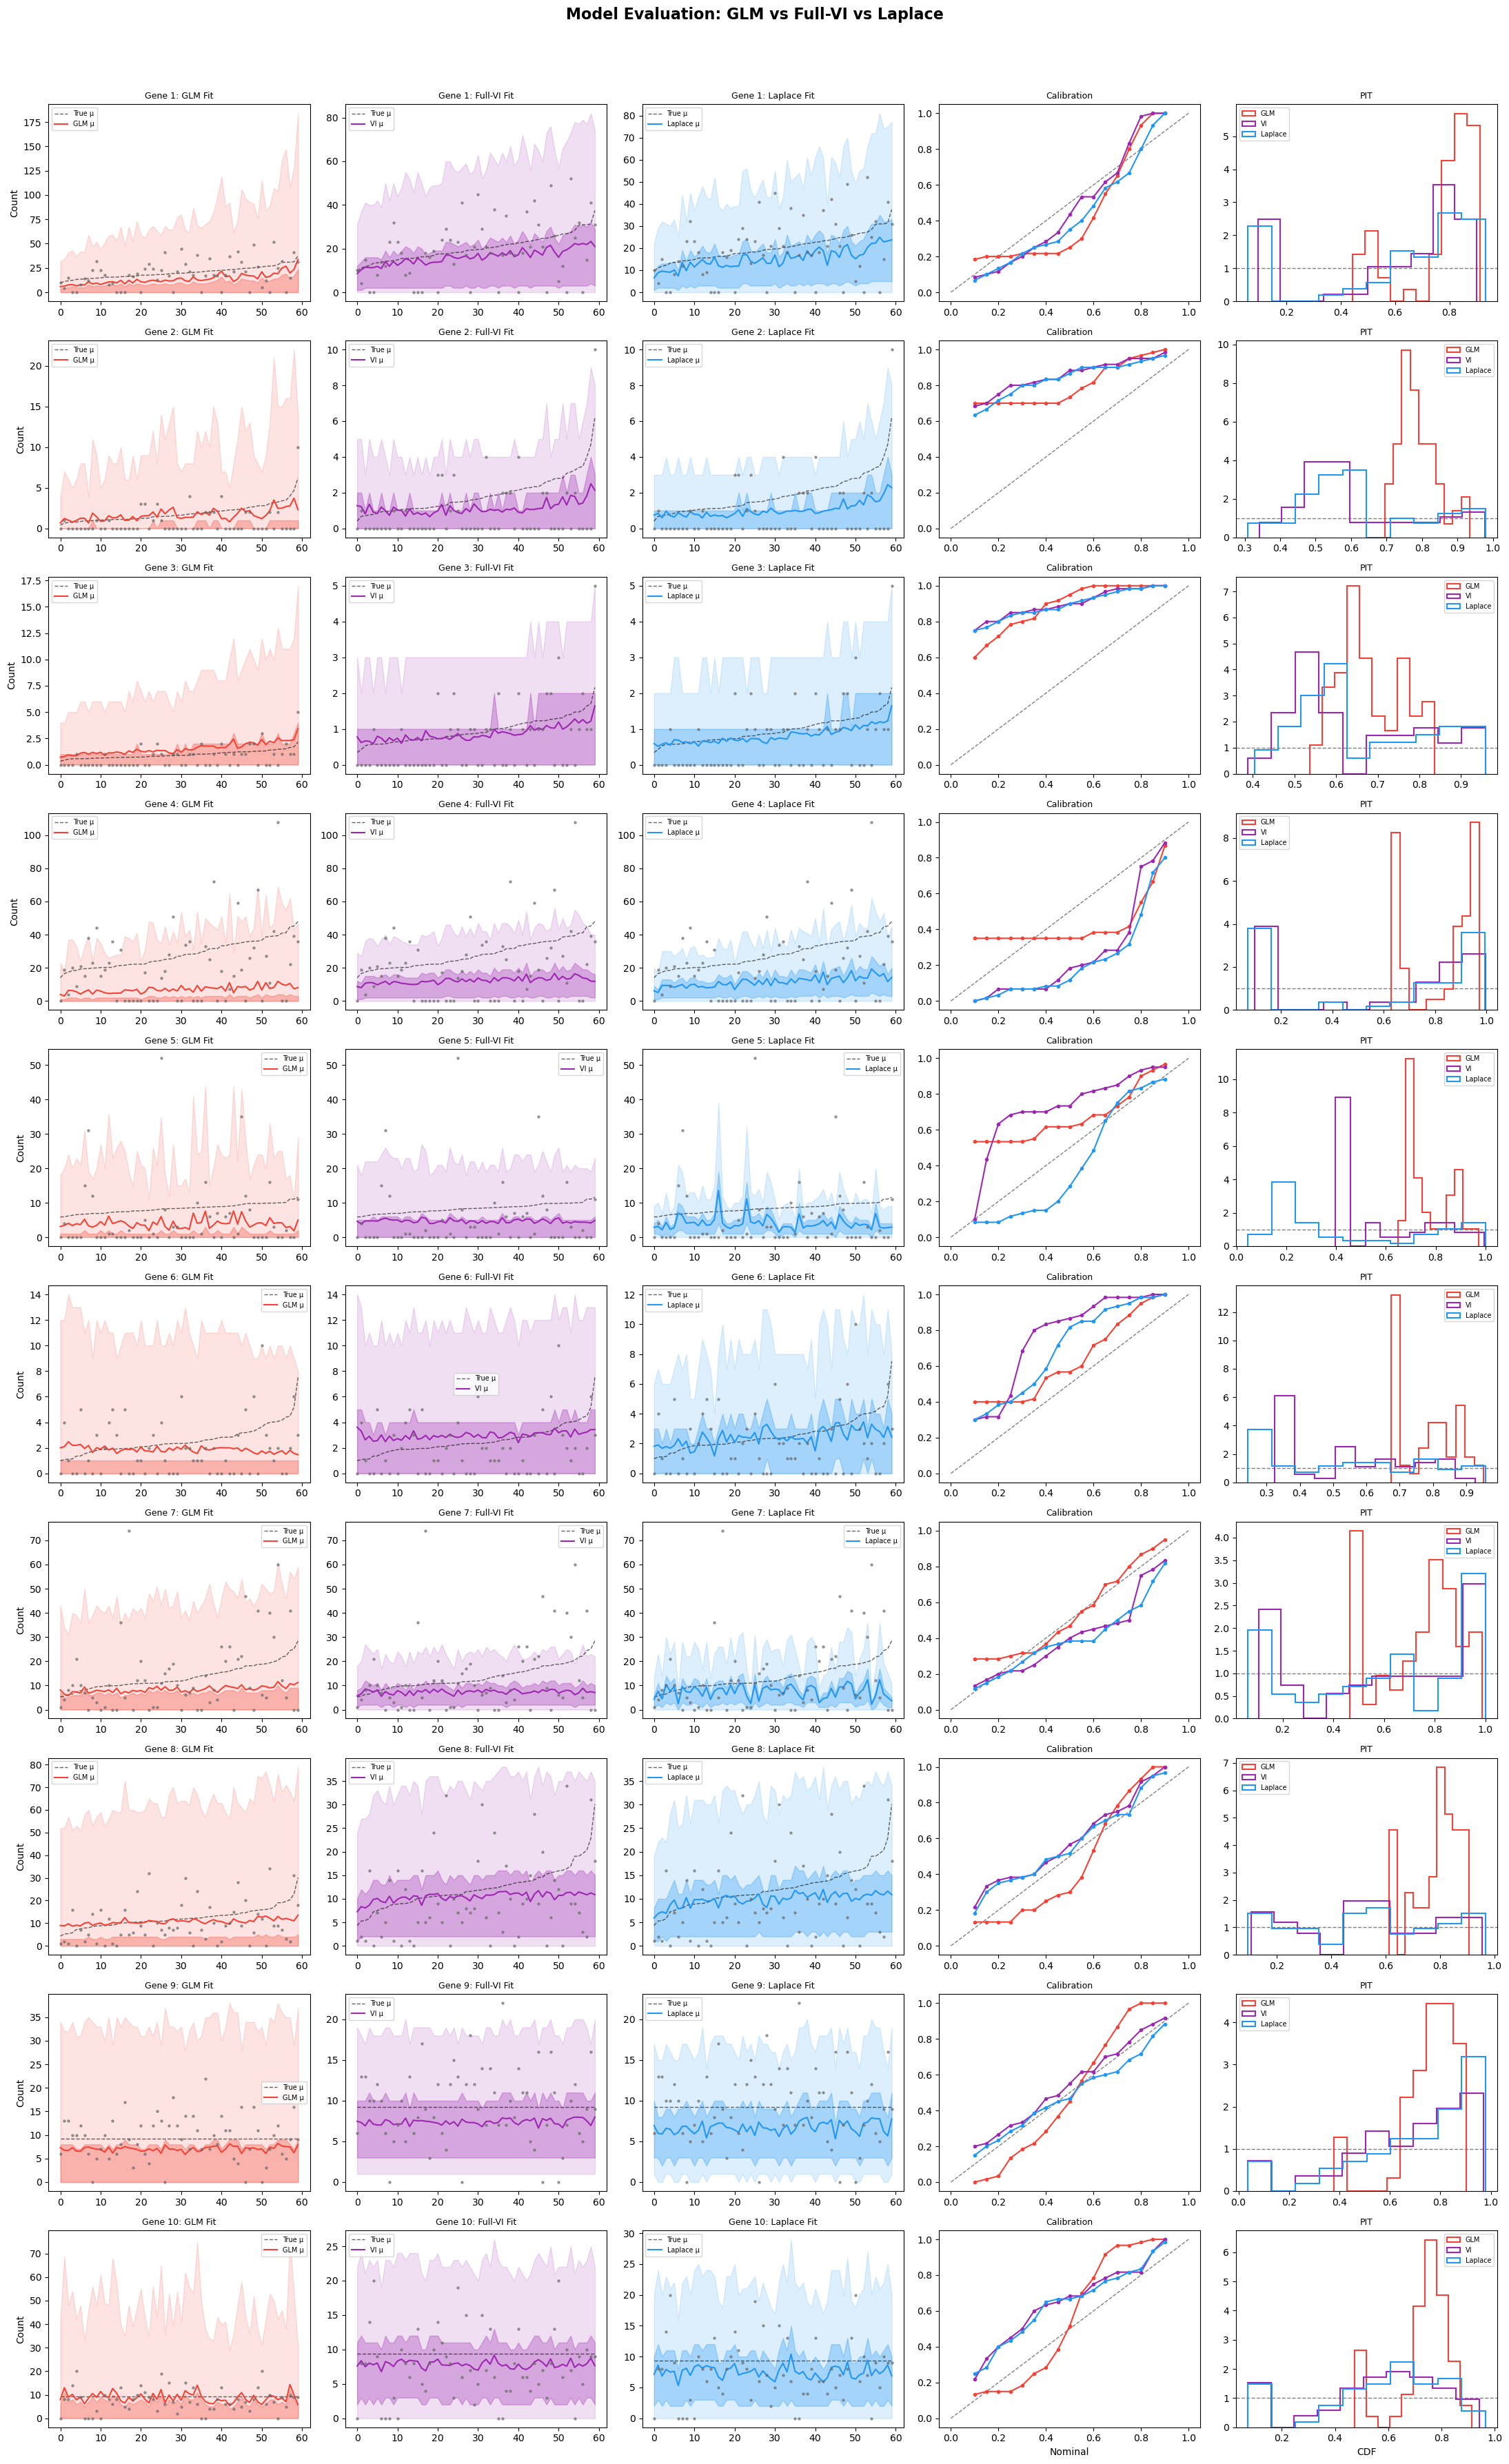

In [60]:
fig, axes = plt.subplots(G, 5, figsize=(22, G * 3.5))
if G == 1: axes = axes[np.newaxis, :]
plt.suptitle("Model Evaluation: GLM vs Full-VI vs Laplace", fontsize=16, fontweight='bold', y=1.02)

alphas = np.linspace(0.1, 0.9, 17)
colors = {'GLM': '#F44336', 'VI': '#9C27B0', 'Laplace': '#2196F3'}

for g in range(G):
    pa = pred_arrays[g]
    y_obs, mu_true = pa['y_te'], pa['mu_true']
    sort_idx = np.argsort(mu_true)
    x_idx = np.arange(len(y_obs))
    ys, mt_s = y_obs[sort_idx], mu_true[sort_idx]
    
    # Helper to plot fitness
    def plot_fit(ax, mu, theta, samples, c_name, title):
        ax.scatter(x_idx, ys, s=5, c='dimgrey', alpha=0.6, zorder=4)
        ax.plot(x_idx, mt_s, 'k--', lw=1, alpha=0.6, label='True μ')
        
        if np.isnan(theta): 
            ax.set_title(f"{title} (Failed)", fontsize=9)
            return
            
        mu_s = mu[sort_idx]
        p_s = np.clip(theta / (theta + mu_s + 1e-8), 1e-6, 1 - 1e-6)
        
        # 90% and 50% Prediction Intervals
        ax.fill_between(x_idx, nbinom.ppf(0.05, theta, p_s), nbinom.ppf(0.95, theta, p_s), color=colors[c_name], alpha=0.15)
        ax.fill_between(x_idx, nbinom.ppf(0.25, theta, p_s), nbinom.ppf(0.75, theta, p_s), color=colors[c_name], alpha=0.3)
        ax.plot(x_idx, mu_s, color=colors[c_name], lw=1.5, label=f'{c_name} μ')
        
        ax.set_title(f"Gene {g+1}: {title}", fontsize=9)
        ax.legend(fontsize=7)
    
    # Col 0: GLM
    plot_fit(axes[g, 0], pa['glm_mu'], pa['glm_theta'], None, 'GLM', 'GLM Fit')
    axes[g, 0].set_ylabel("Count")
    
    # Col 1: Full-VI
    vi_mu_s = np.exp(pa['vi_fs']).mean(0)
    plot_fit(axes[g, 1], pa['vi_mu'], pa['vi_theta'], vi_mu_s, 'VI', 'Full-VI Fit')
    
    # Col 2: Laplace
    lap_mu_s = np.exp(pa['lap_fs']).mean(0)
    plot_fit(axes[g, 2], pa['lap_mu'], pa['lap_theta'], lap_mu_s, 'Laplace', 'Laplace Fit')
    
    # Col 3: Calibration
    ax = axes[g, 3]
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    
    for m_key, c_name in [('glm', 'GLM'), ('vi', 'VI'), ('lap', 'Laplace')]:
        th = pa[f'{m_key}_theta']
        if np.isnan(th): continue
        p_v = np.clip(th / (th + pa[f'{m_key}_mu'] + 1e-8), 1e-6, 1 - 1e-6)
        cov = [((y_obs >= nbinom.ppf((1-a)/2, th, p_v)) & (y_obs <= nbinom.ppf((1+a)/2, th, p_v))).mean() for a in alphas]
        ax.plot(alphas, cov, color=colors[c_name], label=c_name, lw=1.5, marker='.')
        
    ax.set_title("Calibration", fontsize=9)
    if g == G - 1: ax.set_xlabel("Nominal")
    
    # Col 4: PIT
    ax = axes[g, 4]
    ax.axhline(1.0, color='k', lw=1, ls='--', alpha=0.5)
    for m_key, c_name in [('glm', 'GLM'), ('vi', 'VI'), ('lap', 'Laplace')]:
        th = pa[f'{m_key}_theta']
        if np.isnan(th): continue
        p_v = np.clip(th / (th + pa[f'{m_key}_mu'] + 1e-8), 1e-6, 1 - 1e-6)
        pit = nbinom.cdf(y_obs, th, p_v)
        ax.hist(pit, bins=10, density=True, histtype='step', lw=1.5, color=colors[c_name], label=c_name)
        
    ax.set_title("PIT", fontsize=9)
    if g == G - 1: ax.set_xlabel("CDF")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()